# Анализ мотивации абитуриентов к поступлению в магистратуру DH — воспроизводимый пайплайн

1) Предобработка (очистка, лемматизация **Stanza**, стоп‑слова **NLTK + доменные**)  
2) Эмбеддинги **Sentence-BERT** (`paraphrase-multilingual-MiniLM-L12-v2`, 384)  
3) Тематическое моделирование **BERTopic + HDBSCAN(min_cluster_size=3)**, перебор `k ∈ {3,5,7,10}`, когерентность **c_v**  
4) Визуализация **UMAP**  
5) Дендрограмма тем по косинусным расстояниям между TF‑IDF центроидами  
6) χ²‑анализ связи тем с метаданными  
7) Пилотная классификация тем: **LogisticRegression(class_weight='balanced') + SMOTE + CalibratedClassifierCV**


In [ ]:
# !pip install -U pandas numpy scipy scikit-learn matplotlib nltk stanza sentence-transformers bertopic hdbscan umap-learn gensim imbalanced-learn

In [200]:
import os
import re
import inspect
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords

import stanza
from sentence_transformers import SentenceTransformer

from bertopic import BERTopic
import hdbscan
import umap

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation

from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

from scipy.stats import chi2_contingency
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import CalibratedClassifierCV
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


In [202]:
DATA_PATH = "dataset_with_topics.csv"  
TEXT_COL  = "motivation_fragment"         
ID_COL    = "id"                      
UNIT_FOR_TOPICS = "fragments" 
UNIT_FOR_CHI2 = "letters"     
MIN_CLUSTER_SIZE = 2
Ks = [3, 5, 7, 10]  
FORCE_K = 3         

# Папка с результатами
OUTDIR = "outputs"
os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(os.path.join(OUTDIR, "figures"), exist_ok=True)
os.makedirs(os.path.join(OUTDIR, "reports"), exist_ok=True)


In [204]:
# ---------------------------
# 1) Загрузка данных
# ---------------------------
df = pd.read_csv(DATA_PATH)
print("Rows:", len(df))
print("Columns:", list(df.columns))

if ID_COL in df.columns:
    print("Unique letters (id):", df[ID_COL].nunique())

df.head()


Rows: 331
Columns: ['id', 'text_full', 'motivation_fragment', 'label', 'поступление', 'специальность', 'мп', 'год', 'topic']
Unique letters (id): 91


,id,text_full,motivation_fragment,label,поступление,специальность,мп,год,topic
0,1721,Мотивационное письмо %name%\n\nВ этом году я з...,поможет мне развить необходимые для работы и п...,Мотивация поступления,1,история,1,2020,0
1,1721,Мотивационное письмо %name%\n\nВ этом году я з...,мне хотелось совместить в себе «гуманитария» и...,Мотивация поступления,1,история,1,2020,0
2,1721,Мотивационное письмо %name%\n\nВ этом году я з...,мне нравится образовательный процесс в Высшей ...,Мотивация поступления,1,история,1,2020,0
3,17250026733,**Для образовательной программы магистратуры «...,сменить вектор своего сознания в сторону IT,Мотивация поступления,1,международные отношения,1,2021,-1
4,17250026733,**Для образовательной программы магистратуры «...,Сказать определенно: захочу ли я применять пол...,Мотивация поступления,1,международные отношения,1,2021,0


In [206]:
# ---------------------------
# 2) Формируем датасет для тематического моделирования
# ---------------------------
df_topics = df.copy()
df_topics["text"] = df_topics[TEXT_COL].astype(str)

if UNIT_FOR_TOPICS == "letters":
    df_topics = (
        df.groupby(ID_COL, as_index=False)
          .agg(
              text=(TEXT_COL, lambda x: " ".join(map(str, x))),
              **{c: (c, "first") for c in ["поступление", "год", "специальность"] if c in df.columns}
          )
    )
df_topics.head()


,id,text_full,motivation_fragment,label,поступление,специальность,мп,год,topic,text
0,1721,Мотивационное письмо %name%\n\nВ этом году я з...,поможет мне развить необходимые для работы и п...,Мотивация поступления,1,история,1,2020,0,поможет мне развить необходимые для работы и п...
1,1721,Мотивационное письмо %name%\n\nВ этом году я з...,мне хотелось совместить в себе «гуманитария» и...,Мотивация поступления,1,история,1,2020,0,мне хотелось совместить в себе «гуманитария» и...
2,1721,Мотивационное письмо %name%\n\nВ этом году я з...,мне нравится образовательный процесс в Высшей ...,Мотивация поступления,1,история,1,2020,0,мне нравится образовательный процесс в Высшей ...
3,17250026733,**Для образовательной программы магистратуры «...,сменить вектор своего сознания в сторону IT,Мотивация поступления,1,международные отношения,1,2021,-1,сменить вектор своего сознания в сторону IT
4,17250026733,**Для образовательной программы магистратуры «...,Сказать определенно: захочу ли я применять пол...,Мотивация поступления,1,международные отношения,1,2021,0,Сказать определенно: захочу ли я применять пол...


In [243]:
# ---------------------------
# 3) Предобработка: очистка + лемматизация Stanza + стоп-слова
# ---------------------------

# NLTK stopwords
try:
    _ = stopwords.words("russian")
except LookupError:
    nltk.download("stopwords")
RUS_STOP = set(stopwords.words("russian"))

DOMAIN_STOP = {
    "ниу","вшэ","hse",
    "магистратура","магистр","магистерский","программа",
    "цифровой","гуманитарный","humanities","dh","digital",
    "письмо","мотивационный","школа","метод",
}

STOPWORDS = RUS_STOP | DOMAIN_STOP

def clean_text(s: str) -> str:
    s = str(s).lower()

    s = re.sub(r"[^0-9a-zа-яё\s]", " ", s, flags=re.IGNORECASE)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def stanza_download_ru():
    stanza.download("ru")
try:
    nlp = stanza.Pipeline("ru", processors="tokenize,pos,lemma", tokenize_no_ssplit=True, verbose=False)
except Exception:
    stanza_download_ru()
    nlp = stanza.Pipeline("ru", processors="tokenize,pos,lemma", tokenize_no_ssplit=True, verbose=False)

def lemmatize_text(text: str) -> list[str]:
    text = clean_text(text)
    if not text:
        return []
    doc = nlp(text)
    lemmas = []
    for sent in doc.sentences:
        for w in sent.words:
            lemma = (w.lemma or "").lower().strip()
            if not lemma:
                continue
            if w.upos not in {"NOUN","VERB","ADJ"}:
                continue
            if lemma.isdigit():
                continue
            if len(lemma) < 2:
                continue
            if lemma in STOPWORDS:
                continue
            lemmas.append(lemma)
    return lemmas

tokens = [lemmatize_text(t) for t in df_topics["text"].tolist()]
docs_clean = [" ".join(toks) for toks in tokens]

print("RAW:", df_topics["text"].iloc[0])
print("CLEAN:", docs_clean[0])
print("Avg tokens per doc:", float(np.mean([len(t) for t in tokens])))

RAW: поможет мне развить необходимые для работы и профессионального развития навыки
CLEAN: помочь развить необходимый работа профессиональный развитие навык
Avg tokens per doc: 8.836858006042297


In [210]:
# ---------------------------
# 4) Эмбеддинги Sentence-BERT
# ---------------------------
embed_model_name = "paraphrase-multilingual-MiniLM-L12-v2"
embedder = SentenceTransformer(embed_model_name)

embeddings = embedder.encode(
    docs_clean,
    show_progress_bar=True,
    normalize_embeddings=True
)
embeddings = np.asarray(embeddings)


Batches:   0%|          | 0/11 [00:00<?, ?it/s]

## 5) KMeans и LDA

сравнительные подходы


In [211]:
# --- 5.1) KMeans на эмбеддингах (часто кластеры идут по длине/шуму коротких фрагментов) ---
from sklearn.preprocessing import StandardScaler

k = 3
X = embeddings
km = KMeans(n_clusters=k, random_state=42, n_init="auto")
km_labels = km.fit_predict(X)

df_topics["kmeans_cluster"] = km_labels
df_topics["text_len"] = [len(t.split()) for t in docs_clean]

print("KMeans cluster sizes:")
print(df_topics["kmeans_cluster"].value_counts().sort_index())

print("\nMean length per cluster (diag for 'кластеризация по длине'):")
print(df_topics.groupby("kmeans_cluster")["text_len"].mean().round(2))


KMeans cluster sizes:
kmeans_cluster
0    147
1     96
2     88
Name: count, dtype: int64

Mean length per cluster (diag for 'кластеризация по длине'):
kmeans_cluster
0     8.38
1     6.22
2    12.45
Name: text_len, dtype: float64


In [214]:
# --- 5.2) LDA. На коротких текстах часто хуже ловит контекст/синонимы ---
vectorizer_lda = CountVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    min_df=1,
    max_df=0.95
)
X_bow = vectorizer_lda.fit_transform(docs_clean)

lda_k = 3
lda = LatentDirichletAllocation(n_components=lda_k, random_state=42, learning_method="batch")
lda_topics = lda.fit_transform(X_bow)

vocab = np.array(vectorizer_lda.get_feature_names_out())

def top_words(components, topn=10):
    out = []
    for ti, comp in enumerate(components):
        idx = np.argsort(comp)[::-1][:topn]
        out.append((ti, vocab[idx].tolist()))
    return out

for ti, words in top_words(lda.components_, topn=10):
    print(f"LDA topic {ti}:", ", ".join(words))


LDA topic 0: деятельность, продолжить, научный, исследовательский, работа, заниматься, наука, хотеть, исследование, сфера
LDA topic 1: данные, знание, развитие, анализ, возможность, работа, хотеть, работать, направление, наука
LDA topic 2: исследование, новый, область, наука, данные, проект, образовательный, технология, язык, современный


## 6) BERTopic + HDBSCAN и когерентность c_v (основной метод)

In [216]:
from sentence_transformers import SentenceTransformer
embedder = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embeddings = embedder.encode(docs_clean, show_progress_bar=True, normalize_embeddings=True)

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

In [217]:
import numpy as np
import pandas as pd

from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from bertopic.vectorizers import ClassTfidfTransformer

import umap
import hdbscan


docs_clean = ["" if x is None else str(x) for x in docs_clean]
lens = np.array([len(d.split()) for d in docs_clean])
keep_idx = np.where(lens >= 3)[0]

print("Docs total:", len(docs_clean))
print("Docs kept:", len(keep_idx), "| dropped:", len(docs_clean) - len(keep_idx))

docs_bt = [docs_clean[i] for i in keep_idx]

embedder = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
emb_bt = embedder.encode(docs_bt, show_progress_bar=True, normalize_embeddings=True)

vectorizer_model = CountVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    min_df=1,
    max_df=1.0
)

# 4) UMAP + HDBSCAN
umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=2,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

# 5) c-TF-IDF + KeyBERTInspired
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=False)
representation_model = KeyBERTInspired()

topic_model = BERTopic(
    embedding_model=embedder,              
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    representation_model=representation_model,
    nr_topics=5,
    verbose=False
)

topics, probs = topic_model.fit_transform(docs_bt, emb_bt)

print("Topics found (excluding -1):", len([t for t in set(topics) if t != -1]))
print(pd.Series(topics).value_counts().sort_index())

for tid in sorted(topic_model.get_topics().keys()):
    if tid == -1:
        continue
    top = topic_model.get_topic(tid) or []
    print(f"Topic {tid}: " + ", ".join([w for w, _ in top[:10]]))

Docs total: 331
Docs kept: 315 | dropped: 16


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Topics found (excluding -1): 4
-1     38
 0    193
 1     68
 2     13
 3      3
Name: count, dtype: int64
Topic 0: научный, наука, исследовательский, изучение, исследование, академический, заниматься, аспирантура, карьера, проект
Topic 1: программирование, оцифровка, данные, анализировать, визуализация, анализ, лингвистика, литературоведение, изучать, текстовый
Topic 2: россия, российский, русский, русскоязычный, славянский, зарубежный, международный, компания, организация, японистика
Topic 3: китайский, китай, язык, история, будущее, технология, знание, проект, использовать, 


In [220]:
for tid in sorted(topic_model.get_topics().keys()):
    if tid == -1:
        continue
    top = topic_model.get_topic(tid) or []
    print(f"Topic {tid}: " + ", ".join([w for w, _ in top[:10]]))

Topic 0: научный, наука, исследовательский, изучение, исследование, академический, заниматься, аспирантура, карьера, проект
Topic 1: программирование, оцифровка, данные, анализировать, визуализация, анализ, лингвистика, литературоведение, изучать, текстовый
Topic 2: россия, российский, русский, русскоязычный, славянский, зарубежный, международный, компания, организация, японистика
Topic 3: китайский, китай, язык, история, будущее, технология, знание, проект, использовать, 


## 7) Визуализация UMAP (как в тексте)

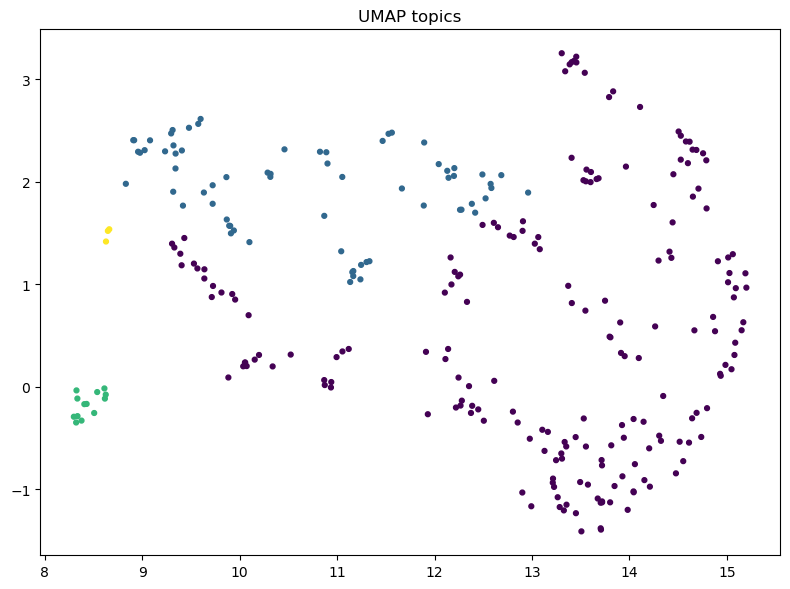

In [222]:
import numpy as np
import umap
import matplotlib.pyplot as plt

topics_arr = np.asarray(topics)
assert emb_bt.shape[0] == len(topics_arr), (emb_bt.shape[0], len(topics_arr))

umap_2d = umap.UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)
xy = umap_2d.fit_transform(emb_bt)

mask = topics_arr != -1

plt.figure(figsize=(8, 6))
if mask.sum() < 2 or len(np.unique(topics_arr[mask])) < 2:
    plt.scatter(xy[mask, 0], xy[mask, 1], s=12)
else:
    plt.scatter(xy[mask, 0], xy[mask, 1], c=topics_arr[mask], s=12)

plt.title("UMAP topics")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "figures", "umap_topics.png"), dpi=200)
plt.show()

## 8) Примеры текстов по темам (быстро для интерпретации)

In [224]:
import numpy as np

topics_arr = np.asarray(topics)

# topics_full длины 331: по умолчанию -1, а на keep_idx вставляем реальные темы
topics_full = np.full(len(df_topics_out), -1, dtype=int)
topics_full[np.asarray(keep_idx)] = topics_arr

df_topics_out["topic"] = topics_full
for tid in sorted(df_topics_out["topic"].unique()):
    if tid == -1:
        continue
    print("\n" + "="*60)
    print("Topic", tid, "| top words:", [w for (w,_) in (topic_model.get_topic(tid) or [])][:10])
    sample_texts = df_topics_out.loc[df_topics_out["topic"] == tid, "text"].head(10).tolist()
    for i, t in enumerate(sample_texts, 1):
        print(f"{i}) {t[:300]}{'...' if len(t) > 300 else ''}")


Topic 0 | top words: ['научный', 'наука', 'исследовательский', 'изучение', 'исследование', 'академический', 'заниматься', 'аспирантура', 'карьера', 'проект']
1) поможет мне развить необходимые для работы и профессионального развития навыки
2) мне нравится образовательный процесс в Высшей школе экономики
3) сменить вектор своего сознания в сторону IT
4) Сказать определенно: захочу ли я применять полученные навыки в академической среде, музейной, либо же коммерческой, не могу. 
5) мне хотелось бы трудиться в той сфере, которая имеет прикладное применение и которая дает реальные полезные «плоды»
6) я, безусловно, люблю гуманитарные науки, но мне не всегда нравятся методы, которыми руководствуются в их изучении
7) ВУЗ славится современными технологиями в обучении, ярким преподавательским составом, широкими образовательными возможностями
8) направление аккумулирует то, чем я уже владею и то, чему хочу научиться и в чем вижу практическое, проектное применение
9) здесь заложен огромный смысл

## 9) Дендрограмма тем (TF‑IDF центроиды + cosine)

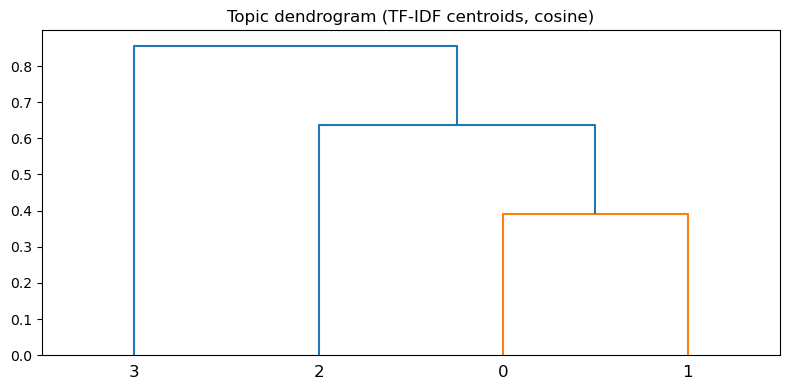

In [226]:
df_tmp = df_topics_out[df_topics_out["topic"] != -1].copy()
topic_ids = sorted(df_tmp["topic"].unique().tolist())

if len(topic_ids) < 2:
    print("Not enough topics for dendrogram.")
else:
    tfidf = TfidfVectorizer(
        tokenizer=str.split,
        preprocessor=None,
        token_pattern=None,
        min_df=1,
        max_df=0.95
    )
    X = tfidf.fit_transform(df_tmp["text"].astype(str).tolist())

    centroids = []
    for tid in topic_ids:
        idx = np.where(df_tmp["topic"].values == tid)[0]
        centroids.append(X[idx].mean(axis=0))
    C = np.vstack([c.A1 for c in centroids])

    D = pdist(C, metric="cosine")
    Z = linkage(D, method="average")

    plt.figure(figsize=(8, 4))
    dendrogram(Z, labels=[str(t) for t in topic_ids])
    plt.title("Topic dendrogram (TF-IDF centroids, cosine)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "figures", "dendrogram_topics.png"), dpi=200)
    plt.show()


## 10) χ²‑анализ связи тем с метаданными


In [240]:
def chi2_test(df_in, topic_col="topic", factor_col="поступление"):
    if factor_col not in df_in.columns:
        return None
    d = df_in[df_in[topic_col] != -1].copy()
    d = d.dropna(subset=[factor_col])
    if d.empty:
        return None
    ct = pd.crosstab(d[topic_col], d[factor_col])
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return None
    chi2, p, dof, exp = chi2_contingency(ct)
    return float(p), ct

# 10.1) χ² на уровне фрагментов
rows = []
for col in ["поступление", "год", "специальность"]:
    res = chi2_test(df_topics_out, topic_col="topic", factor_col=col)
    if res is None:
        continue
    p, ct = res
    rows.append({"unit": "fragments", "factor": col, "p_value": p, "table_shape": str(ct.shape)})
chi2_frag = pd.DataFrame(rows)
display(chi2_frag)

# 10.2) χ² на уровне писем (если есть id)
chi2_letters = pd.DataFrame()
if ID_COL in df.columns and UNIT_FOR_CHI2 == "letters":
    if "topic" not in df_topics_out.columns:
        df_topics_out["topic"] = topics
    df_frag = df.copy()
    df_frag["topic"] = df_topics_out["topic"].values

    def mode_topic(s):
        s = [x for x in s if x != -1]
        if not s:
            return -1
        return pd.Series(s).mode().iloc[0]

    agg = {
        "topic": ("topic", mode_topic),
        **{c: (c, "first") for c in ["поступление", "год", "специальность"] if c in df_frag.columns}
    }
    df_letter_topic = df_frag.groupby(ID_COL, as_index=False).agg(**{k: v for k,v in agg.items()})

    rows2 = []
    for col in ["поступление", "год", "специальность"]:
        res = chi2_test(df_letter_topic, topic_col="topic", factor_col=col)
        if res is None:
            continue
        p, ct = res
        rows2.append({"unit": "letters(mode topic)", "factor": col, "p_value": p, "table_shape": str(ct.shape)})

    chi2_letters = pd.DataFrame(rows2)
    display(chi2_letters)

chi2_all = pd.concat([chi2_frag, chi2_letters], ignore_index=True)
chi2_all.to_csv(os.path.join(OUTDIR, "reports", "chi2_pvalues.csv"), index=False, encoding="utf-8")


,unit,factor,p_value,table_shape
0,fragments,поступление,0.158054,"(4, 2)"
1,fragments,год,0.852332,"(4, 6)"
2,fragments,специальность,0.514894,"(4, 23)"


,unit,factor,p_value,table_shape
0,letters(mode topic),поступление,0.330002,"(3, 2)"
1,letters(mode topic),год,0.287260,"(3, 6)"
2,letters(mode topic),специальность,0.980234,"(3, 23)"


## 11) Пилотная классификация тем 

Признаки: эмбеддинги SBERT  
Модель: LogisticRegression(class_weight='balanced')  
Дисбаланс: SMOTE (k_neighbors подбираем адаптивно)  
Калибровка: CalibratedClassifierCV(sigmoid)


In [238]:
mask = topics != -1
X = embeddings[mask]
y = topics[mask]

if len(np.unique(y)) < 1 or len(y) < 1:
    print("No labeled data")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.25,
        random_state=42,
        stratify=y
    )

    _, counts = np.unique(y_train, return_counts=True)
    min_class = int(counts.min())
    k_neighbors = max(1, min(5, min_class - 1))

    smote = SMOTE(k_neighbors=k_neighbors, random_state=42)
    lr = LogisticRegression(max_iter=2000, class_weight="balanced")

    pipe = ImbPipeline([("smote", smote), ("lr", lr)])

    cv = max(2, min(5, min_class)) 
    clf = CalibratedClassifierCV(pipe, method="sigmoid", cv=cv)

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    report = classification_report(y_test, y_pred, digits=2)
    print(report)

    with open(os.path.join(OUTDIR, "reports", "classification_report.txt"), "w", encoding="utf-8") as f:
        f.write(report)

    cm = confusion_matrix(y_test, y_pred, labels=sorted(np.unique(y)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(np.unique(y)))
    disp.plot()
    plt.title("Confusion matrix")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "figures", "confusion_matrix.png"), dpi=200)
    plt.show()


TypeError: object of type 'int' has no len()